# [LAB99] AutoML > 01-PyCaret

## #01. PyCaret 개요

- **파이썬 기반 AutoML 라이브러리**
  - 전처리 → 모델 비교 → 튜닝 → 평가 → 해석을 **한 줄 코드로 자동화**
  - 머신러닝 “실무 파이프라인 전체”를 빠르게 실험하는 도구
- 개별 알고리즘 구현 능력 → **모델 선택·비교·의사결정 능력**으로 확장
  - 실험 비용 감소 (시간, 코드, 실수)
  - 캡스톤·포트폴리오·프로토타입에 매우 유용

### 🧠 기존 학습과의 연결

| 기존에 배운 것 | PyCaret에서의 역할 |
|---|---|
| train / test 분리 | `setup()` 내부에서 자동 수행 |
| 스케일링, 인코딩 | 자동 전처리 |
| 여러 분류모형 학습 | `compare_models()` |
| GridSearchCV | `tune_model()` |
| 성능 비교 | 자동 랭킹 테이블 |
| SHAP, 중요도 | `interpret_model()` |

### PyCaret 작업 흐름

```
데이터 준비
   ↓
setup()
   ↓
compare_models()
   ↓
select / tune_model()
   ↓
evaluate_model()
   ↓
interpret_model()
```

### PyCaret의 장점

- 코드량 극단적으로 감소
- 모델 간 성능 비교가 직관적
- 실험 재현성 높음
- SHAP 기반 해석 바로 가능

### PyCaret의 한계

- 내부 동작이 블랙박스처럼 보일 수 있음
- 전처리 세부 제어는 제한적
- AutoML 결과를 비판적으로 해석하지 않으면 위험

**👉 기초 머신러닝을 배운 뒤에 써야 의미 있음**

### 수업에서의 위치 정리

- ❌ 머신러닝 입문용 아님
- ✅ 분류모형 학습 후 정리·확장 단계
- ✅ “실무에서는 이렇게 실험한다”를 보여주는 도구


## #02. 준비작업

### [1] 패키지 참조

초기 로딩시간이 오래 걸린다.

In [12]:
from hossam import *
from pandas import concat
from pycaret.regression import *

### [2] 데이터 불러오기 + 인덱스 설정 + 카테고리 타입 지정

In [2]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


## #02. PyCaret setup

### [1] `setup()`

```python
# 코드 구문 설명입니다.
s = RegressionExperiment()
s.setup(data, target, **options)
```

In [3]:
s = RegressionExperiment()

s.setup(
    #-------------------------------------
    # 기본 설정 (필수 지정)
    #-------------------------------------
    # 데이터셋 지정
    data=origin,
    # 예측 목표 변수 지정
    target="sales",
    # 랜덤 시드 고정
    session_id=52,
    # 훈련 데이터 비율 (기본값=0.7)
    train_size=0.75,
    # 교차검증 폴드 수 지정
    fold=5,
    # 처리과정 출력 안함 (기본값 True, False 권장. 출력 과정이 다소 길어질 수 있음)
    verbose=False,
    # GPU 사용 여부 지정 (기본값 False) - True로 설정하면 컴퓨터 환경에 따라 지원 안될 경우 에러 발생
    use_gpu=False,
    #-------------------------------------
    # 전처리 설정 (1)
    #-------------------------------------
    # 범주형 변수 지정(기본값 None)
    categorical_features=['weekend', 'holiday'],
    # 생략할 변수 지정(기본값 None)
    ignore_features=[],
    # 데이터 정규화/표준화 활성화(기본값 False)
    normalize=True,
    # 데이터 정규화/표준화 방법 선택 (zscore가 StandardScaler와 동일)
    # 'minmax', 'maxabs', 'robust', 'zscore'
    normalize_method='zscore',
    #-------------------------------------
    # 전처리 설정 (2) - 아래 기능은 사용하지 말고, 데이터 별도의 전처리 단계를 거치는 것을 권장
    #-------------------------------------
    # 이상치 제거 (기본값 False, IQR 범위 밖의 값을 삭제함)
    remove_outliers=False,
    # 이상치 제거 임계값 (기본값 0.05, 상하위 몇 %를 이상치로 간주할지 지정)
    outliers_threshold=0.05,
    # 종속변수 변환 (기본값 False)
    transform_target=False,
    # 변수 선택 (기본값 False)
    feature_selection=False
)

### [2] Setup 결과 확인

In [4]:
s.pull()

,Description,Value
0,Session id,52
1,Target,sales
2,Target type,Regression
3,Original data shape,"(353, 9)"
4,Transformed data shape,"(353, 9)"
5,Transformed train set shape,"(264, 9)"
6,Transformed test set shape,"(89, 9)"
7,Numeric features,6
8,Categorical features,2
9,Preprocess,True


| No | Description                 | Value            | 의미 설명                  |
| -: | --------------------------- | ---------------- | ---------------------- |
|  0 | Session id                  | 52               | 실험 재현을 위한 난수 고정값       |
|  1 | Target                      | sales            | 예측하려는 종속변수 이름          |
|  2 | Target type                 | Regression       | 회귀 문제로 설정됨             |
|  3 | Original data shape         | (353, 9)         | 전처리 전 원본 데이터 크기 (행, 열) |
|  4 | Transformed data shape      | (353, 9)         | 전처리 후 전체 데이터 크기        |
|  5 | Transformed train set shape | (264, 9)         | 전처리 후 학습 데이터 크기        |
|  6 | Transformed test set shape  | (89, 9)          | 전처리 후 테스트 데이터 크기       |
|  7 | Numeric features            | 6                | 수치형 독립변수 개수            |
|  8 | Categorical features        | 2                | 범주형 독립변수 개수            |
|  9 | Preprocess                  | True             | PyCaret 자동 전처리 수행 여부   |
| 10 | Imputation type             | simple           | 결측치 처리 방식 (단순 대체)      |
| 11 | Numeric imputation          | mean             | 수치형 결측치를 평균값으로 대체      |
| 12 | Categorical imputation      | mode             | 범주형 결측치를 최빈값으로 대체      |
| 13 | Maximum one-hot encoding    | 25               | 범주형 변수당 최대 더미 변수 수 제한  |
| 14 | Encoding method             | None             | 사용자 지정 인코딩 없이 기본 처리    |
| 15 | Normalize                   | True             | 정규화 수행 여부              |
| 16 | Normalize method            | zscore           | Z-score 방식 표준화 적용      |
| 17 | Fold Generator              | KFold            | 교차검증 분할 방식             |
| 18 | Fold Number                 | 5                | 교차검증 폴드 수              |
| 19 | CPU Jobs                    | -1               | 사용 가능한 모든 CPU 코어 사용    |
| 20 | Use GPU                     | False            | GPU 미사용                |
| 21 | Log Experiment              | False            | 실험 로그 자동 기록 미사용        |
| 22 | Experiment Name             | reg-default-name | 실험 이름 (기본값)            |
| 23 | USI                         | acba             | PyCaret 내부 실험 고유 식별자   |

## #03. 단일 모형 구축하기

### [1] 사용할 수 있는 학습 모델의 종류 확인

In [5]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.ElasticNet,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPursuit,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


### [2] 기본 파라미터로 학습하기

- **모델 종류 표의 ID값을 기준으로 특정 알고리즘에 대한 모델을 생성**
  - 모델 선택 단계에서 이미 학습을 마치고 결과가 반환된다.
  - 하이퍼파라미터는 기본값을 사용한다.

In [6]:
model = s.create_model("rf")
model

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1908,0.0553,0.2352,0.6325,0.0135,0.0116
1,0.1624,0.0444,0.2106,0.7492,0.0122,0.0100
2,0.1575,0.0390,0.1976,0.7546,0.0115,0.0097
3,0.1690,0.0441,0.2101,0.6170,0.0121,0.0104
4,0.1956,0.0642,0.2534,0.4657,0.0146,0.0119
Mean,0.1751,0.0494,0.2214,0.6438,0.0128,0.0107
Std,0.0154,0.0091,0.0201,0.1058,0.0011,0.0009


RandomForestRegressor(n_jobs=-1, random_state=52)

### [2] 하이퍼파라미터 튜닝 학습 모델 생성

#### (1) 최적화 관련 파라미터

| 파라미터                 | 설명           | 적용 가능한 값 / 범위                                | **기본값** | **권장값**  |
| -------------------- | ------------ | -------------------------------------------- | ------- | -------- |
| `optimize`           | 최적화 기준 지표    | `"R2"`, `"RMSE"`, `"MAE"`, `"MSE"`, `"MAPE"` | `"R2"`  | `"RMSE"` |
| `choose_better`      | 튜닝 전·후 성능 비교 | `True`, `False`                              | `False` | `True`   |
| `return_train_score` | train 점수 반환  | `True`, `False`                              | `False` | `False`  |


#### (2) 탐색 방식·범위 제어

| 파라미터               | 설명           | 적용 가능한 값 / 범위    | **기본값**          | **권장값**   |
| ------------------ | ------------ | ---------------- | ---------------- | --------- |
| `n_iter`           | 탐색 반복 횟수     | 정수 ≥ 1           | `10`             | `20 ~ 50` |
| `search_algorithm` | 탐색 알고리즘      | `"random"`, `"grid"` | `"random"`       | 기본값       |
| `custom_grid`      | 사용자 지정 탐색 공간 | `dict`           | `None`           | 필요 시만     |

#### (3) 교차검증·재현성

| 파라미터      | 설명        | 적용 가능한 값 / 범위   | **기본값**     | **권장값** |
| --------- | --------- | --------------- | ----------- | ------- |
| `fold`    | CV fold 수 | 정수 ≥ 2          | `setup()` 값 | `3 ~ 5` |
| `round`   | 출력 소수점 자리 | 정수              | `4`         | `4`     |
| `verbose` | 로그 출력     | `True`, `False` | `True`      | `False` |

#### (4) 자원 사용

| 파라미터      | 설명        | 적용 가능한 값 / 범위   | **기본값** | **권장값** |
| --------- | --------- | --------------- | ------- | ------- |
| `n_jobs`  | CPU 병렬 수  | `-1`, 양의 정수     | `-1`    | `-1`    |
| `use_gpu` | GPU 사용 시도 | `True`, `False` | `False` | `False` |


In [7]:
%%time
tuned = s.tune_model(
    estimator=model, 
    optimize="RMSE",
    n_iter=30,
    fold=5,
    choose_better=True,
    verbose=False,
    early_stopping=True,

    # 하이퍼파라미터 탐색 방법(grid=전체탐색, random=무작위탐색)
    search_algorithm="grid",

    # 직접 하이퍼파라미터 범위 구성하기 (생략할 경우 자동 구성함)
    custom_grid={    
        "n_estimators": [300, 500],     # ⭐⭐ 성능 안정화
        "max_depth": [None, 10],        # ⭐⭐ 보조 과적합 제어
        "min_samples_leaf": [5, 10],    # ⭐⭐⭐ 과적합 통제 핵심
        "max_features": ["sqrt", 1.0],  # ⭐⭐⭐ 트리 다양성 핵심
    }
)
tuned

CPU times: user 551 ms, sys: 39.1 ms, total: 590 ms
Wall time: 4.11 s


RandomForestRegressor(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                      random_state=52)

### [3] 하이퍼파라미터 확인

In [8]:
tuned.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 52,
 'verbose': 0,
 'warm_start': False}

### [6] 결과 시각화

시각화는 좀 오래 걸린다. (비동기)

그리고 해석이 좀 어렵다.

안되는 것도 은근히 많다.

차라리 직접 하자

In [ ]:
s.evaluate_model(estimator=tuned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### [7] SHAP (summary)

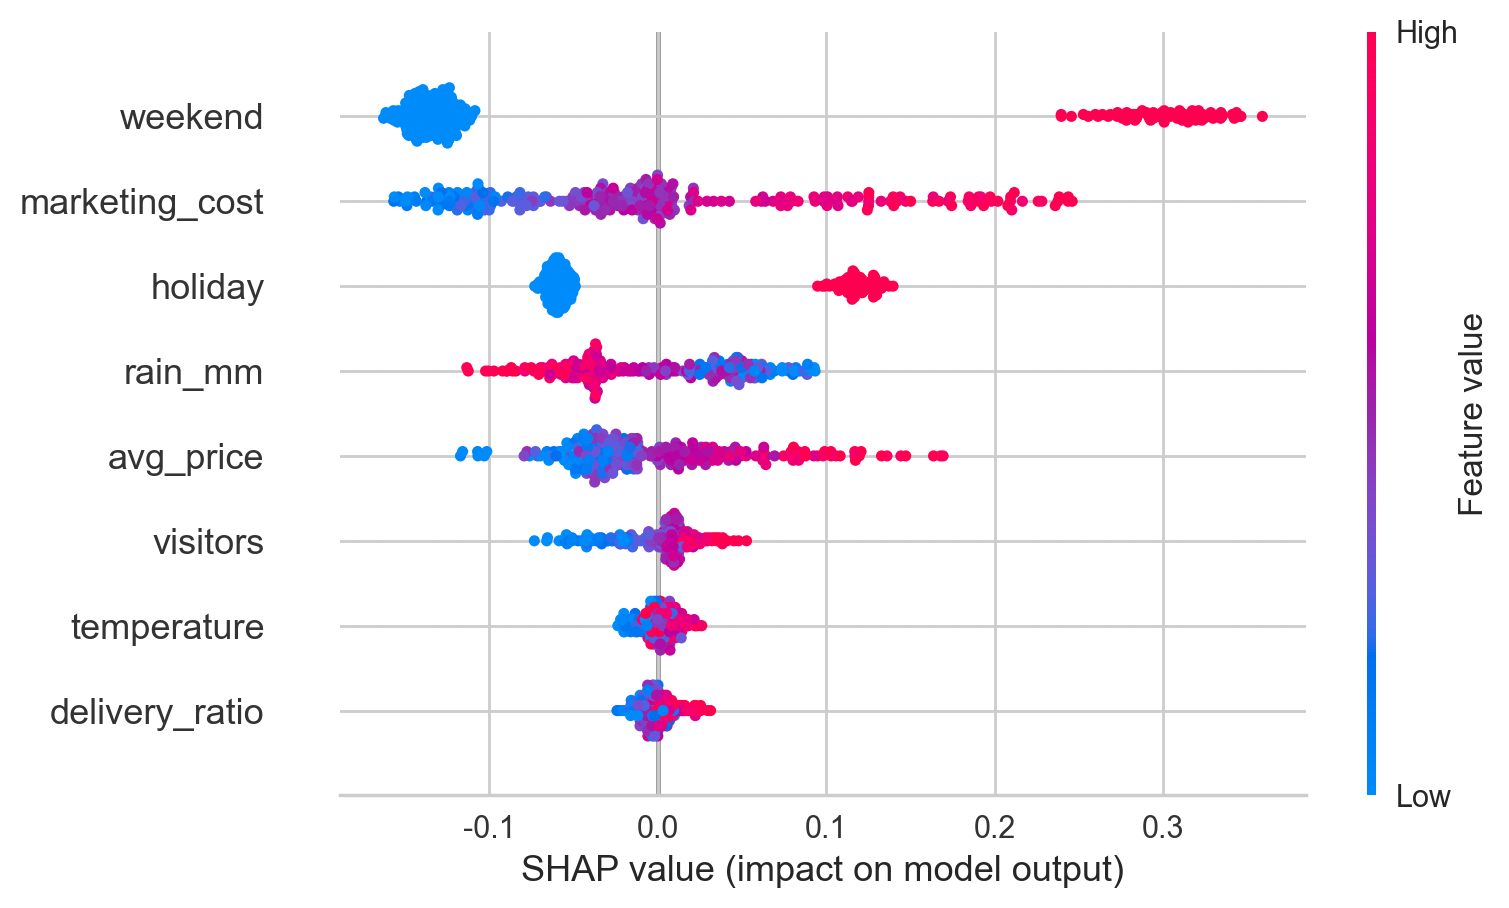

In [10]:
s.interpret_model(estimator=tuned, plot='summary', use_train_data=True)

#### [8] 변수간 관계

`feature` 매개변수를 통해 가장 영향력이 큰 변수와 다른 변수의 관계를 설정할 수 있다.



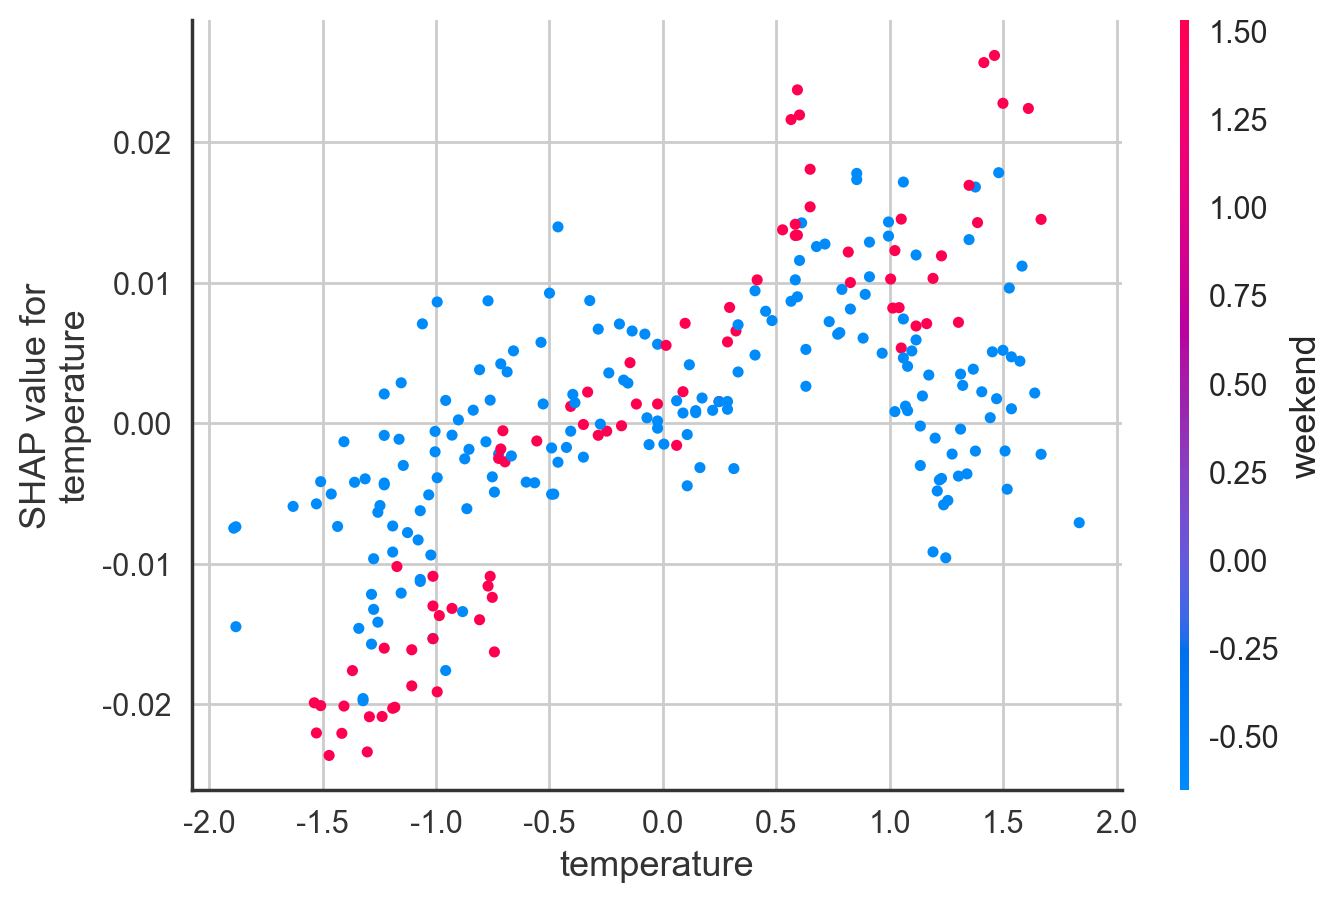

In [11]:
s.interpret_model(estimator=tuned, plot='correlation', use_train_data=True, feature='temperature')

## #04. 분석 결과 직접 확인하기

### [1] 훈련, 검증 데이터 추출

전처리가 완료된 데이터를 반환한다.

`get_config()`는 pycaret.regressor 객체의 메서드

#### 각 데이터 추출

In [13]:
# 원본 독립변수(분할전)
x = s.get_config("X")
y = s.get_config("y")

# 훈련 데이터 (데이터 변환 전)
x_train = s.get_config("X_train")
y_train = s.get_config("y_train")

# 테스트 데이터 (데이터 변환 전)
x_test = s.get_config("X_test")
y_test = s.get_config("y_test")

# 변환된 훈련 데이터
x_train_transformed = s.get_config("X_train_transformed")
y_train_transformed = s.get_config("y_train_transformed")

# 변환된 테스트 데이터
x_test_transformed = s.get_config("X_test_transformed")
y_test_transformed = s.get_config("y_test_transformed")

# 변환된 훈련+테스트 데이터 셋
x_transformed = concat([x_train_transformed, x_test_transformed])
y_transformed = concat([y_train_transformed, y_test_transformed])

(x.shape, y.shape), (x_train.shape, y_train.shape), (x_test.shape, y_test.shape), (x_train_transformed.shape, y_train_transformed.shape), (x_test_transformed.shape, y_test_transformed.shape)

(((353, 8), (353,)),
 ((264, 8), (264,)),
 ((89, 8), (89,)),
 ((264, 8), (264,)),
 ((89, 8), (89,)))

#### 훈련데이터의 독립변수 원본 확인

In [14]:
x_train

,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,
2024-06-11,129,8590,8.987,0.410,2.028,14.200,0,0
2024-06-20,115,22020,8.412,0.380,2.219,8.000,0,0
2024-08-25,115,14630,9.457,0.490,2.251,-2.900,1,1
2024-11-22,137,16830,8.810,0.380,1.194,0.700,0,0
2024-12-30,106,13370,8.537,0.480,2.197,9.600,0,0
...,...,...,...,...,...,...,...,...
2024-03-30,123,13930,7.901,0.530,2.015,27.700,1,1
2024-06-04,114,25370,8.700,0.510,1.589,11.400,0,0
2024-01-14,101,11620,8.319,0.210,0.916,12.900,1,1


#### 훈련 데이터의 독립변수 전처리 결과 확인

In [15]:
x_train_transformed

,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,
2024-06-11,0.916,-1.801,0.229,-0.296,0.594,0.406,-0.731,-0.653
2024-06-20,-0.415,1.761,-0.740,-0.549,0.884,-0.173,-0.731,-0.653
2024-08-25,-0.415,-0.199,1.020,0.378,0.933,-1.191,1.367,1.530
2024-11-22,1.677,0.385,-0.070,-0.549,-0.675,-0.855,-0.731,-0.653
2024-12-30,-1.271,-0.533,-0.529,0.294,0.851,-0.023,-0.731,-0.653
...,...,...,...,...,...,...,...,...
2024-03-30,0.345,-0.384,-1.600,0.715,0.573,1.667,1.367,1.530
2024-06-04,-0.510,2.650,-0.256,0.546,-0.074,0.145,-0.731,-0.653
2024-01-14,-1.747,-0.997,-0.897,-1.981,-1.097,0.285,1.367,1.530


### [2] 성능평가

#### 파이프라인 확인

파이프라인에 머신러닝 모델 자체는 포함되어 있지 않다.

In [16]:
pipeline = s.get_config('pipeline')

display(pipeline)

Pipeline(memory=FastMemory(location=/var/folders/wk/8tx_v8l94cqcwt2b6dzgdc2h0000gn/T/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['visitors', 'avg_price',
                                             'marketing_cost', 'delivery_ratio',
                                             'rain_mm', 'temperature'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['weekend', 'holiday'],
                                    transformer=Simpl...
                 TransformerWrapper(include=['weekend', 'holiday'],
                                    transformer=OrdinalEncoder(cols=['weekend',
                                                                     'holiday'],
                                                               handle_missing='return_nan',
                                                               mapping=[{'col': 'weekend',
                                                                         'data_type': dtype('float64'),
                                                                         'mapping': 0.000    0
1.000    1
NaN     -1
dtype: int64},
                                                                        {'col': 'holiday',
                                                                         'data_type': dtype('float64'),
                                                                         'mapping': 0.000    0
1.000    1
NaN     -1
dtype: int64}]))),
                ('normalize',
                 TransformerWrapper(transformer=StandardScaler()))])

#### 시각화 초기화

PyCaret이 pyplot의 설정을 강제로 수정하기 때문에 되돌리는 작업이 필요하다.

> hossam 라이브러기 기능 사용

In [17]:
init_pyplot()


✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


#### 성능 평가 지표

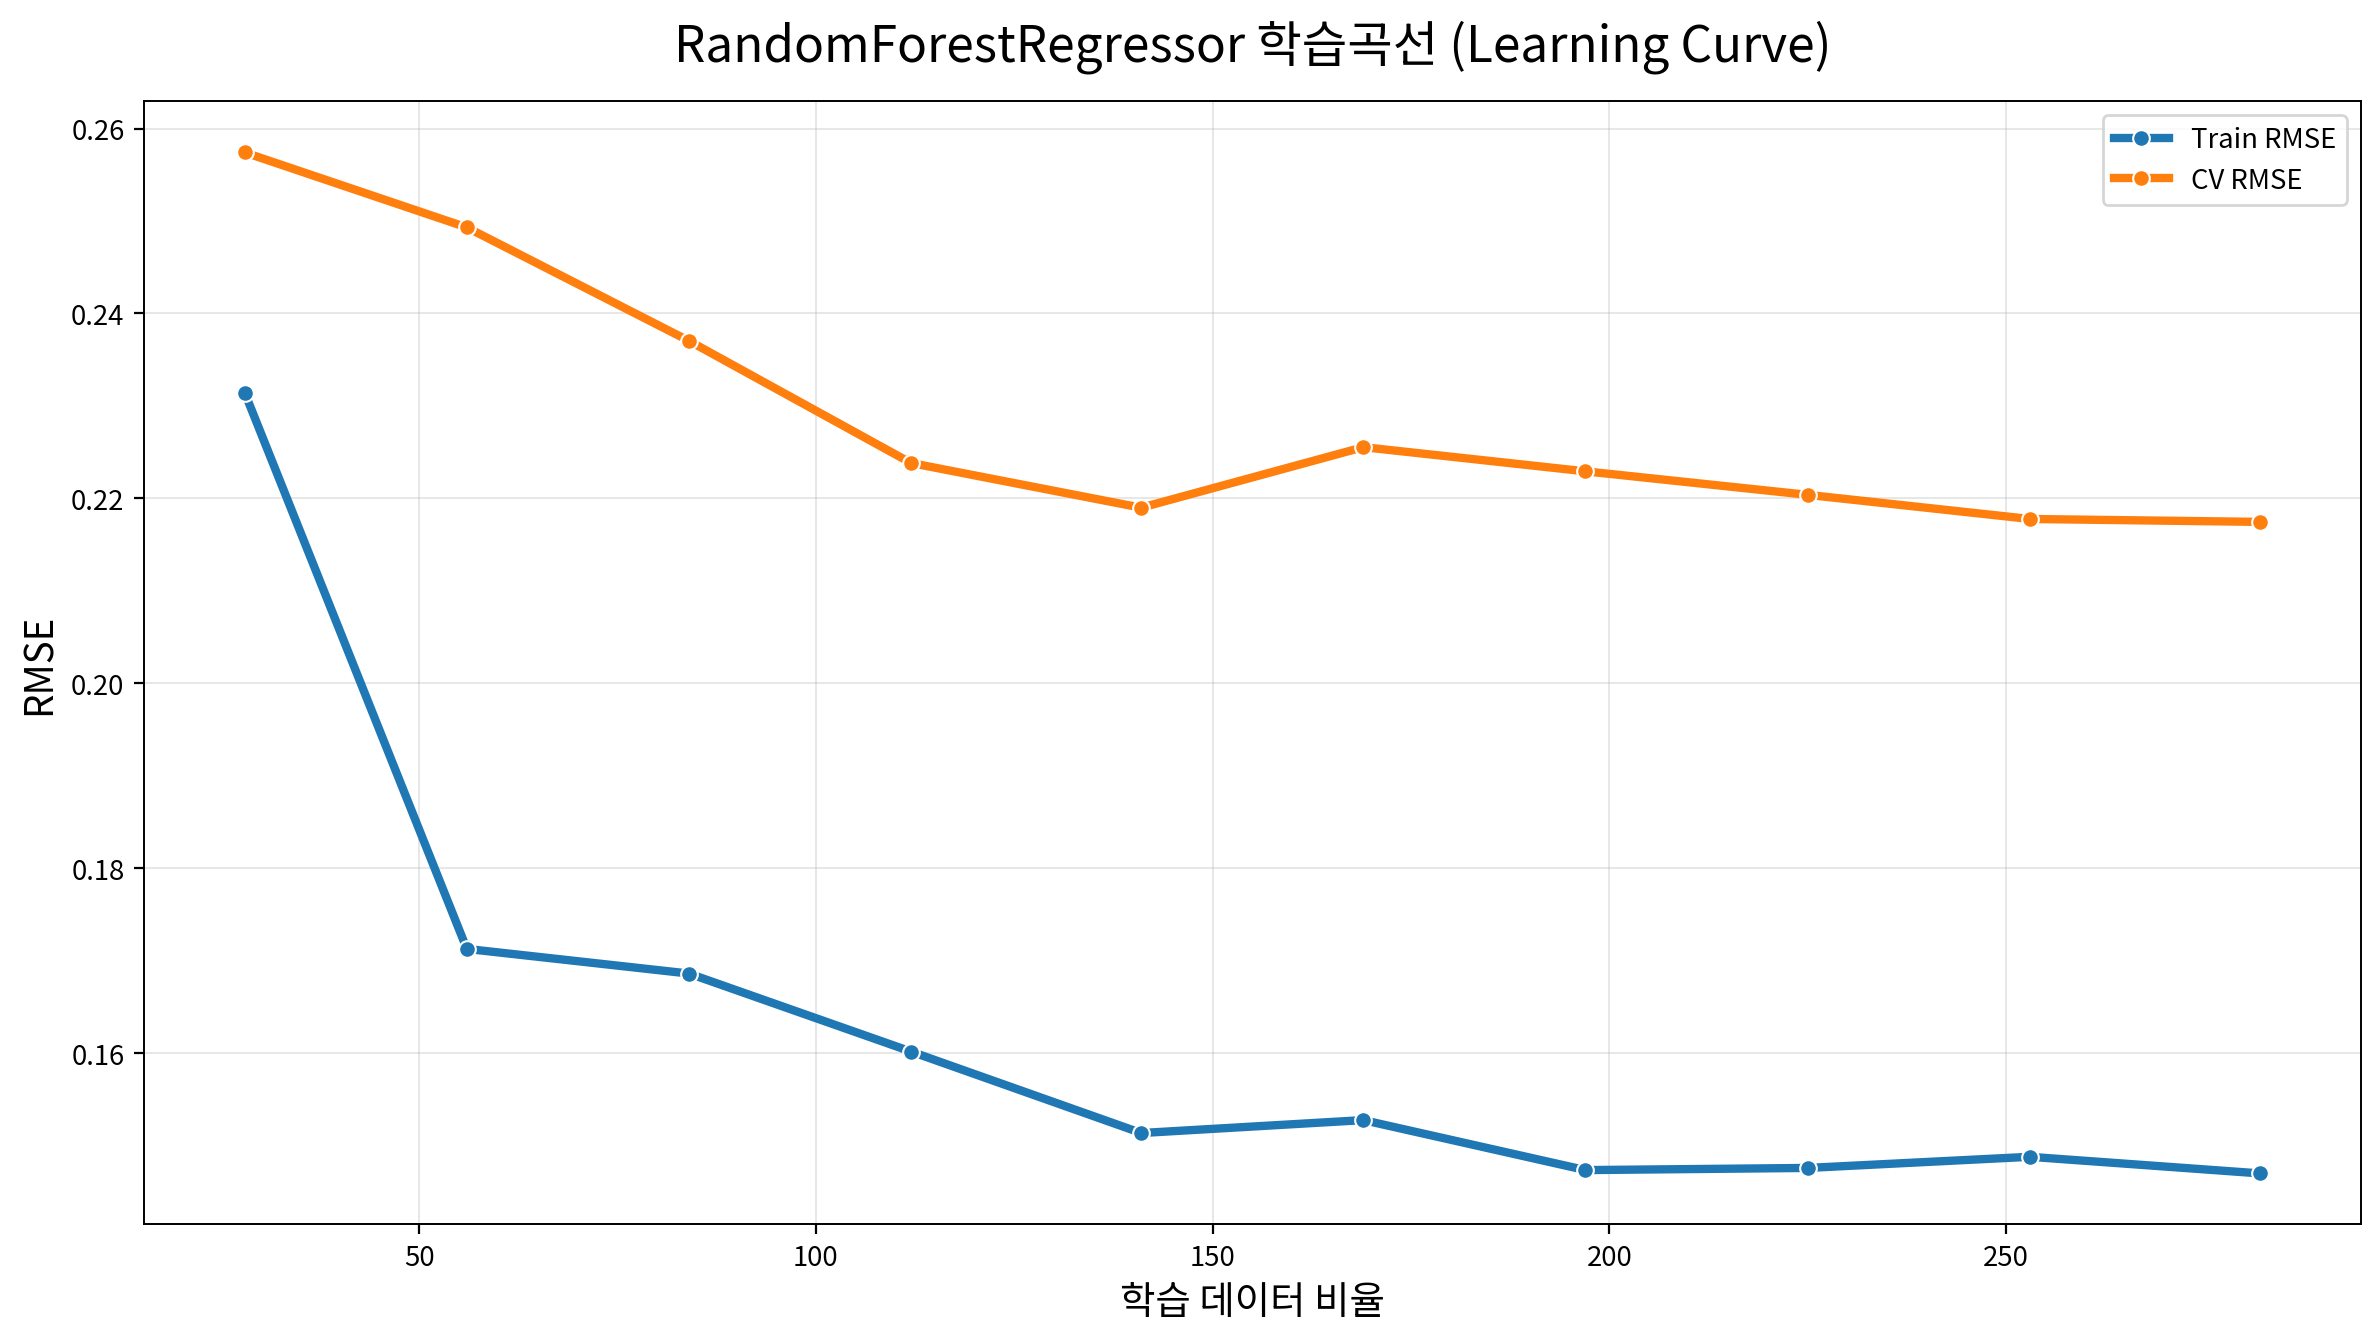

,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균제곱로그오차(MSLE),평균로그오차(RMSLE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
RandomForestRegressor,0.678,0.168,0.046,0.215,0.000,0.012,0.010,0.302,0.147,0.217,0.013,0.676,0.062,⚠️ 과대적합


In [18]:
#%%time
hs_get_score_cv(tuned, x_test_transformed, y_test_transformed, x_transformed, y_transformed)

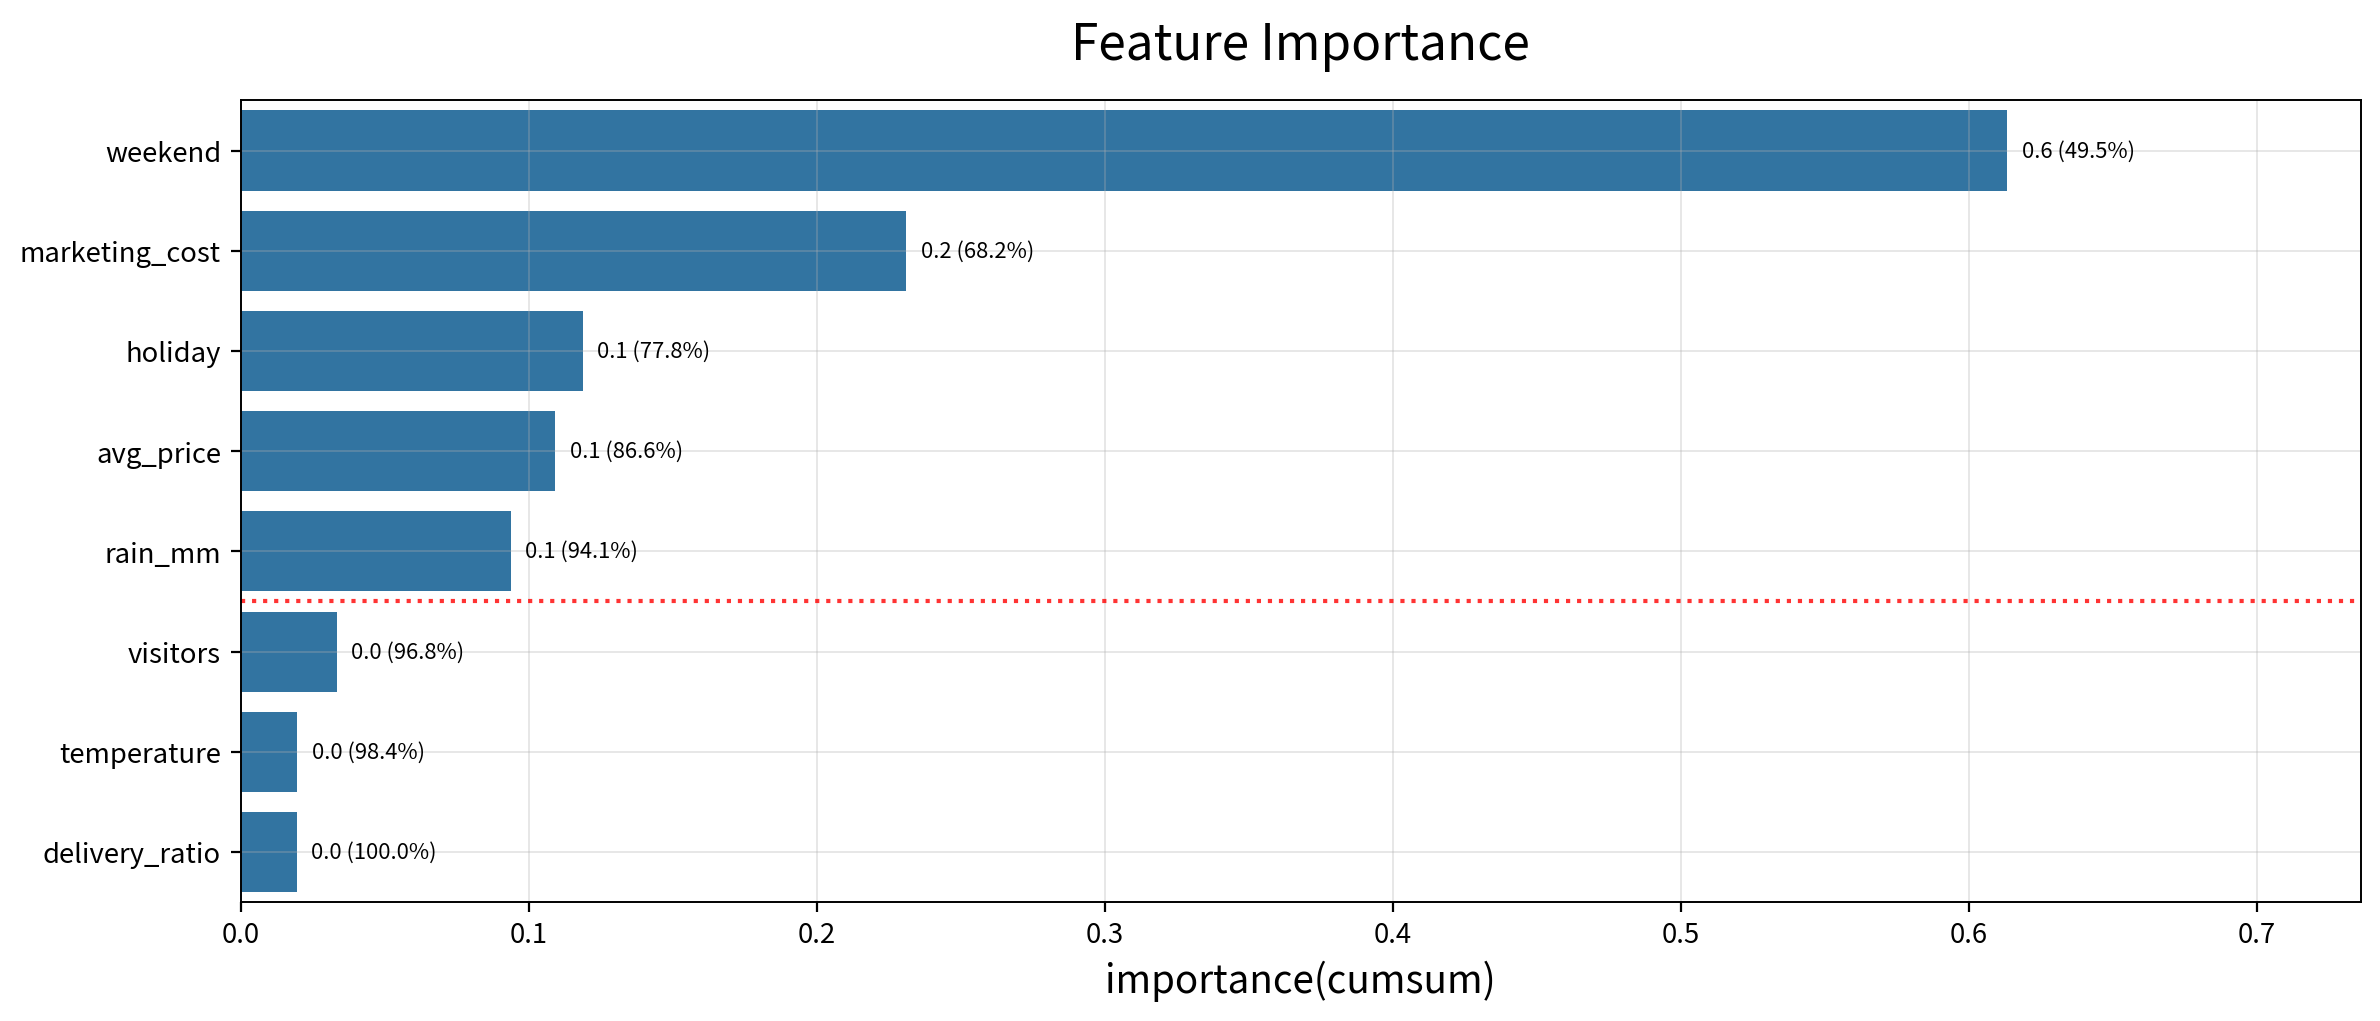

,importance,ratio,cumsum
weekend,0.613,0.495,0.495
marketing_cost,0.231,0.187,0.682
holiday,0.119,0.096,0.778
avg_price,0.109,0.088,0.866
rain_mm,0.094,0.076,0.941
visitors,0.033,0.027,0.968
temperature,0.020,0.016,0.984
delivery_ratio,0.020,0.016,1.000


In [19]:
hs_feature_importance(tuned, x_train_transformed, y_train_transformed)

Using TreeExplainer for tree-based models


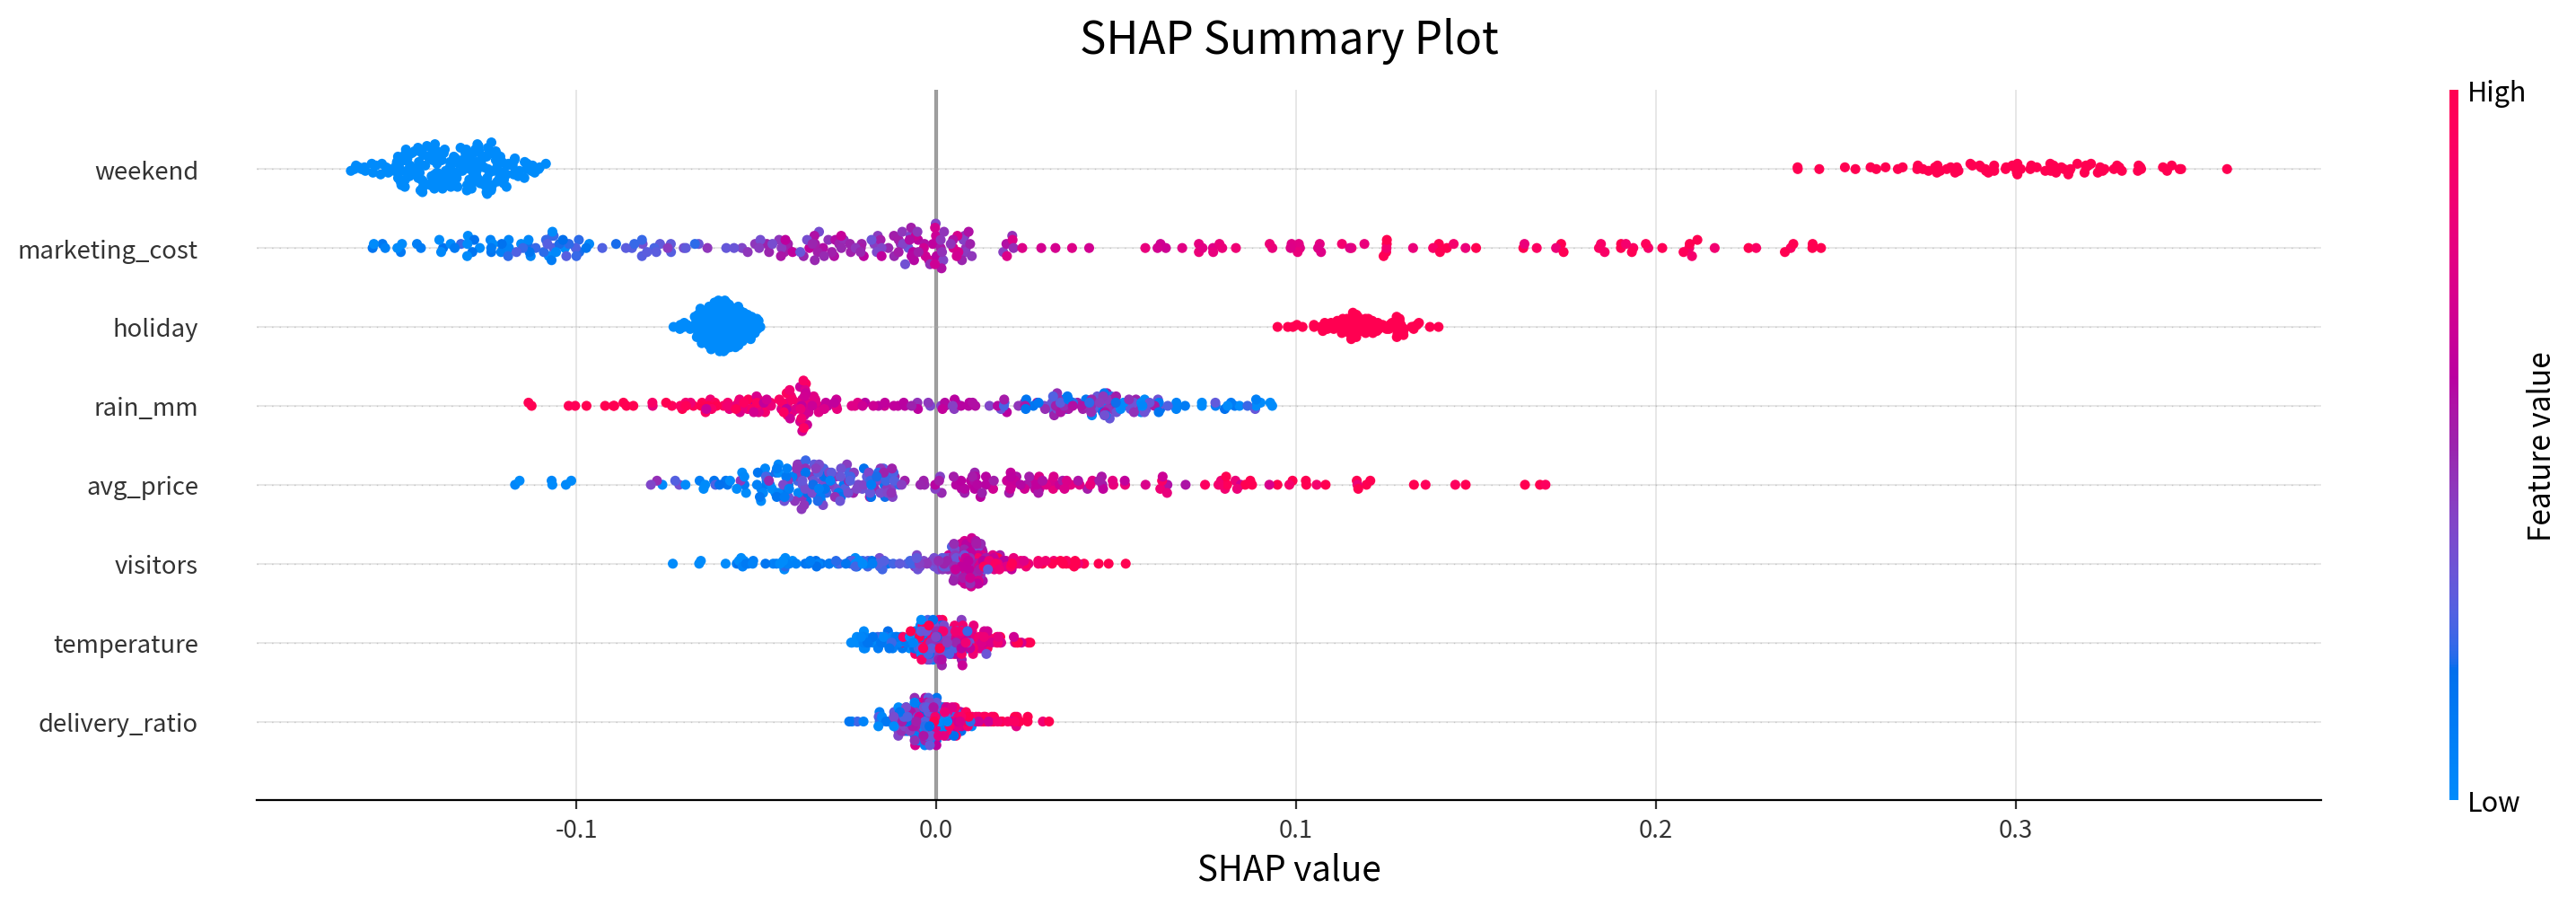

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,weekend,0.184,-0.004,0.200,음(-) 경향,1.088,variable,0.395,0.395,core
1,marketing_cost,0.081,0.001,0.104,양(+) 경향,1.277,variable,0.174,0.569,core
2,holiday,0.080,0.003,0.085,양(+) 경향,1.065,variable,0.171,0.740,core
3,rain_mm,0.046,-0.001,0.051,음(-) 경향,1.113,variable,0.098,0.838,secondary
4,avg_price,0.043,-0.002,0.054,음(-) 경향,1.252,variable,0.092,0.930,secondary
5,visitors,0.018,0.000,0.023,양(+) 경향,1.301,variable,0.038,0.969,secondary
6,temperature,0.008,0.000,0.010,양(+) 경향,1.292,variable,0.017,0.985,secondary
7,delivery_ratio,0.007,-0.000,0.009,음(-) 경향,1.330,variable,0.015,1.000,secondary


In [20]:
df, v = hs_shap_analysis(tuned, x_train_transformed, width=1600)
df